# Rheology Analysis: Rotational Drag vs Z-Height
Cone-plate geometry — torque per RPM fitted via 4 methods

In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 10,
})
print('Imports OK')

Imports OK


In [2]:
# ── Cell 2: Load raw data ─────────────────────────────────────────────────────
RAW_PATH = 'timing_v3.csv'   # adjust path if needed

raw_df = pd.read_csv(RAW_PATH)
print(f'Shape: {raw_df.shape}')
print(f'Z-Height range : {raw_df["Z-Height"].min():.4f}  →  {raw_df["Z-Height"].max():.4f}')
print(f'Elapsed_Time_s : {raw_df["Elapsed_Time_s"].min():.2f}  →  {raw_df["Elapsed_Time_s"].max():.2f}')
raw_df.head(3)

Shape: (713, 25)
Z-Height range : -66.5000  →  -65.9000
Elapsed_Time_s : 5.01  →  115.10


,Z-Height,Elapsed_Time_s,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-65.9,5.03,37.22,35.52,33.01,34.35,33.67,36.53,35.34,34.60,...,28.25,21.61,25.47,27.28,19.85,22.95,20.46,20.57,19.03,17.37
1,-65.9,10.10,37.28,35.59,33.04,34.46,33.77,36.81,35.49,34.98,...,30.44,27.87,28.16,34.08,26.23,27.58,27.36,27.79,24.79,23.54
2,-65.9,15.07,37.31,35.62,33.02,34.50,33.83,36.91,35.47,35.09,...,30.91,30.75,28.80,36.86,29.78,29.31,31.57,32.29,27.54,27.65


In [3]:
# ── Cell 3: Column catalogue & RPM extraction ─────────────────────────────────
torque_cols = [c for c in raw_df.columns if c not in ('Z-Height', 'Elapsed_Time_s')]

def parse_col(col):
    """Return (viscosity_label, rpm_float) from a column name."""
    # Example: '12.5kcp_14.576_torque_%_rpm_3.5'
    parts = col.split('_')
    visc  = parts[0]                     # e.g. '12.5kcp'
    rpm   = float(parts[-1])             # last token is the rpm value
    return visc, rpm

col_meta = {col: parse_col(col) for col in torque_cols}

print(f'{len(torque_cols)} torque columns found.')
print('Sample metadata:')
for col in list(col_meta)[:4]:
    visc, rpm = col_meta[col]
    print(f'  {col!r:45s} → visc={visc}, rpm={rpm}')

23 torque columns found.
Sample metadata:
  '1kcp_1.073_torque_%_rpm_47'                  → visc=1kcp, rpm=47.0
  '2kcp_3.345_torque_%_rpm_15'                  → visc=2kcp, rpm=15.0
  '4kcp_6.603_torque_%_rpm_8'                   → visc=4kcp, rpm=8.0
  '5kcp_5.861_torque_%_rpm_9'                   → visc=5kcp, rpm=9.0


In [4]:
# ── Cell 4: Per-height representative torque (top-10 % of Elapsed_Time_s) ────
#
# For every (Z-Height, column) group, keep only rows whose Elapsed_Time_s
# falls in the top 10th percentile of that height's time range, then average.

def top10_mean(group, col):
    thresh = group['Elapsed_Time_s'].quantile(0.90)
    top    = group.loc[group['Elapsed_Time_s'] >= thresh, col]
    return top.mean()

records = []
for height, grp in raw_df.groupby('Z-Height'):
    row = {'Height': height}
    for col in torque_cols:
        row[col] = top10_mean(grp, col)
    records.append(row)

rep_df = pd.DataFrame(records).sort_values('Height').reset_index(drop=True)
print(f'Representative dataframe shape: {rep_df.shape}')
rep_df.head()

Representative dataframe shape: (31, 24)


,Height,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,20kcp_24.396_torque_%_rpm_2.1,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-66.50,65.52,67.463333,63.970000,61.706667,66.886667,67.790000,60.320000,60.590000,56.666667,...,64.740000,59.143333,64.813333,74.640000,60.143333,68.690000,70.596667,62.086667,63.333333,51.706667
1,-66.48,58.94,67.130000,64.850000,64.540000,62.286667,70.950000,60.826667,58.896667,59.246667,...,59.040000,59.326667,65.586667,74.650000,61.480000,65.446667,75.016667,60.456667,64.680000,61.923333
2,-66.46,58.34,67.403333,67.723333,66.673333,68.776667,70.913333,65.483333,61.266667,64.746667,...,64.940000,59.140000,65.516667,74.133333,63.566667,67.743333,71.623333,62.823333,66.020000,61.790000
3,-66.44,69.30,66.973333,68.740000,67.280000,68.196667,73.396667,64.880000,63.810000,60.533333,...,65.826667,59.030000,63.850000,71.393333,64.420000,66.556667,70.676667,63.090000,67.416667,59.703333
4,-66.42,62.64,67.186667,69.140000,67.493333,69.630000,74.250000,64.280000,64.050000,60.106667,...,66.653333,58.900000,58.886667,73.866667,66.593333,64.623333,70.713333,65.070000,67.176667,54.013333


In [5]:
# ── Cell 5: Backup before any trimming ───────────────────────────────────────
backup_df = rep_df.copy()
print('Backup saved (backup_df).')

Backup saved (backup_df).


In [6]:
# ── Cell 6: Trim thresholds ───────────────────────────────────────────────────
# Bottom trim: data BELOW this height is removed (set to NaN)
# Top    trim: data ABOVE this height is removed (set to NaN)
# None  → no trim on that side

trim_values = {
    '1kcp_1.073_torque_%_rpm_47'       : -66.22,
    '2kcp_3.345_torque_%_rpm_15'       : -66.22,
    '4kcp_6.603_torque_%_rpm_8'        : -66.34,
    '5kcp_5.861_torque_%_rpm_9'        : -66.34,
    '8kcp_8.946_torque_%_rpm_5.6'      : -66.30,
    '10kcp_9.152_torque_%_rpm_5.5'     : -66.32,
    '12.5kcp_14.576_torque_%_rpm_3.5'  : -66.26,
    '15kcp_19.036_torque_%_rpm_2.6'    : -66.32,
    '20kcp_24.396_torque_%_rpm_2.1'    : -66.24,
    '25kcp_22.760_torque_%_rpm_2.2'    : -66.36,
    '30kcp_31.903_torque_%_rpm_1.7'    : -66.26,
    '35kcp_63.253_torque_%_rpm_0.8'    : -66.24,
    '40kcp_62.756_torque_%_rpm_0.8'    : -66.24,
    '45kcp_40.820_torque_%_rpm_1.2'    : -66.34,
    '50kcp_79.653_torque_%_rpm_0.6'    : -66.24,
    '55kcp_48.553_torque_%_rpm_1'      : -66.44,
    '60kcp_68.953_torque_%_rpm_0.8'    : -66.24,
    '70kcp_87.046_torque_%_rpm_0.5'    : -66.26,
    '75kcp_70.730_torque_%_rpm_0.7'    : -66.34,
    '80kcp_103.800_torque_%_rpm_0.5'   : -66.26,
    '90kcp_102.466_torque_%_rpm_0.5'   : -66.24,
    '95kcp_93.400_torque_%_rpm_0.5'    : -66.32,
    '100kcp_124.033_torque_%_rpm_0.4'  : -66.24,
}

trim_top_values = {
    '1kcp_1.073_torque_%_rpm_47'       : None,
    '2kcp_3.345_torque_%_rpm_15'       : None,
    '4kcp_6.603_torque_%_rpm_8'        : -65.92,
    '5kcp_5.861_torque_%_rpm_9'        : -66.00,
    '8kcp_8.946_torque_%_rpm_5.6'      : -65.92,
    '10kcp_9.152_torque_%_rpm_5.5'     : None,
    '12.5kcp_14.576_torque_%_rpm_3.5'  : None,
    '15kcp_19.036_torque_%_rpm_2.6'    : -66.10,
    '20kcp_24.396_torque_%_rpm_2.1'    : None,
    '25kcp_22.760_torque_%_rpm_2.2'    : None,
    '30kcp_31.903_torque_%_rpm_1.7'    : None,
    '35kcp_63.253_torque_%_rpm_0.8'    : None,
    '40kcp_62.756_torque_%_rpm_0.8'    : None,
    '45kcp_40.820_torque_%_rpm_1.2'    : None,
    '50kcp_79.653_torque_%_rpm_0.6'    : None,
    '55kcp_48.553_torque_%_rpm_1'      : -65.94,
    '60kcp_68.953_torque_%_rpm_0.8'    : None,
    '70kcp_87.046_torque_%_rpm_0.5'    : None,
    '75kcp_70.730_torque_%_rpm_0.7'    : None,
    '80kcp_103.800_torque_%_rpm_0.5'   : None,
    '90kcp_102.466_torque_%_rpm_0.5'   : None,
    '95kcp_93.400_torque_%_rpm_0.5'    : None,
    '100kcp_124.033_torque_%_rpm_0.4'  : None,
}

print('Trim thresholds defined.')

Trim thresholds defined.


In [7]:
# ── Cell 7: Apply trim (re-runnable — always restores from backup first) ──────
updated_df = backup_df.copy()

for col in torque_cols:
    bot = trim_values.get(col)
    top = trim_top_values.get(col)
    if bot is not None:
        updated_df.loc[updated_df['Height'] < bot, col] = np.nan
    if top is not None:
        updated_df.loc[updated_df['Height'] > top, col] = np.nan

# Report NaN counts
nan_counts = updated_df[torque_cols].isna().sum()
print('NaN counts per column after trim:')
print(nan_counts[nan_counts > 0].to_string())

NaN counts per column after trim:
1kcp_1.073_torque_%_rpm_47         14
2kcp_3.345_torque_%_rpm_15         14
4kcp_6.603_torque_%_rpm_8           9
5kcp_5.861_torque_%_rpm_9          13
8kcp_8.946_torque_%_rpm_5.6        11
10kcp_9.152_torque_%_rpm_5.5        9
12.5kcp_14.576_torque_%_rpm_3.5    12
15kcp_19.036_torque_%_rpm_2.6      19
20kcp_24.396_torque_%_rpm_2.1      13
25kcp_22.760_torque_%_rpm_2.2       7
30kcp_31.903_torque_%_rpm_1.7      12
35kcp_63.253_torque_%_rpm_0.8      13
40kcp_62.756_torque_%_rpm_0.8      13
45kcp_40.820_torque_%_rpm_1.2       8
50kcp_79.653_torque_%_rpm_0.6      13
55kcp_48.553_torque_%_rpm_1         5
60kcp_68.953_torque_%_rpm_0.8      13
70kcp_87.046_torque_%_rpm_0.5      12
75kcp_70.730_torque_%_rpm_0.7       8
80kcp_103.800_torque_%_rpm_0.5     12
90kcp_102.466_torque_%_rpm_0.5     13
95kcp_93.400_torque_%_rpm_0.5       9
100kcp_124.033_torque_%_rpm_0.4    13


In [8]:
# ── Cell 8: Per-column height normalisation ────────────────────────────────────
# Zero each column at its own bottom-trim point so that h = 0 sits just
# below the first valid data row.  The singularity (h → 0) therefore lies
# outside the measurement window (h > 0 for all fitted points).

norm_df = updated_df.copy()   # Height column stays as raw Z-Height

# For each column, compute the per-column normalised height series
height_norm = {}   # key=col, value=Series aligned to norm_df index

for col in torque_cols:
    valid_mask = norm_df[col].notna()
    if valid_mask.any():
        h_zero = norm_df.loc[valid_mask, 'Height'].min()   # bottom trim point
    else:
        h_zero = norm_df['Height'].min()
    height_norm[col] = norm_df['Height'] - h_zero   # shift so minimum → 0

print('Height normalisation complete (singularity at h=0, below all valid data).')

# Quick sanity check: all normalised heights for valid rows should be >= 0
for col in list(torque_cols)[:3]:
    valid = norm_df[col].notna()
    h = height_norm[col][valid]
    print(f'  {col[:30]:30s}  h_norm in [{h.min():.4f}, {h.max():.4f}]')

Height normalisation complete (singularity at h=0, below all valid data).
  1kcp_1.073_torque_%_rpm_47      h_norm in [0.0000, 0.3200]
  2kcp_3.345_torque_%_rpm_15      h_norm in [0.0000, 0.3200]
  4kcp_6.603_torque_%_rpm_8       h_norm in [0.0000, 0.4200]


In [9]:
# ── Cell 9: Compute rotational drag  (T / RPM) ───────────────────────────────
drag_df = norm_df[['Height']].copy()

for col in torque_cols:
    _, rpm = col_meta[col]
    drag_df[col] = norm_df[col] / rpm

print('Rotational drag (torque / rpm) computed.')
drag_df.head(3)

Rotational drag (torque / rpm) computed.


,Height,1kcp_1.073_torque_%_rpm_47,2kcp_3.345_torque_%_rpm_15,4kcp_6.603_torque_%_rpm_8,5kcp_5.861_torque_%_rpm_9,8kcp_8.946_torque_%_rpm_5.6,10kcp_9.152_torque_%_rpm_5.5,12.5kcp_14.576_torque_%_rpm_3.5,15kcp_19.036_torque_%_rpm_2.6,20kcp_24.396_torque_%_rpm_2.1,...,45kcp_40.820_torque_%_rpm_1.2,50kcp_79.653_torque_%_rpm_0.6,55kcp_48.553_torque_%_rpm_1,60kcp_68.953_torque_%_rpm_0.8,70kcp_87.046_torque_%_rpm_0.5,75kcp_70.730_torque_%_rpm_0.7,80kcp_103.800_torque_%_rpm_0.5,90kcp_102.466_torque_%_rpm_0.5,95kcp_93.400_torque_%_rpm_0.5,100kcp_124.033_torque_%_rpm_0.4
0,-66.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-66.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-66.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


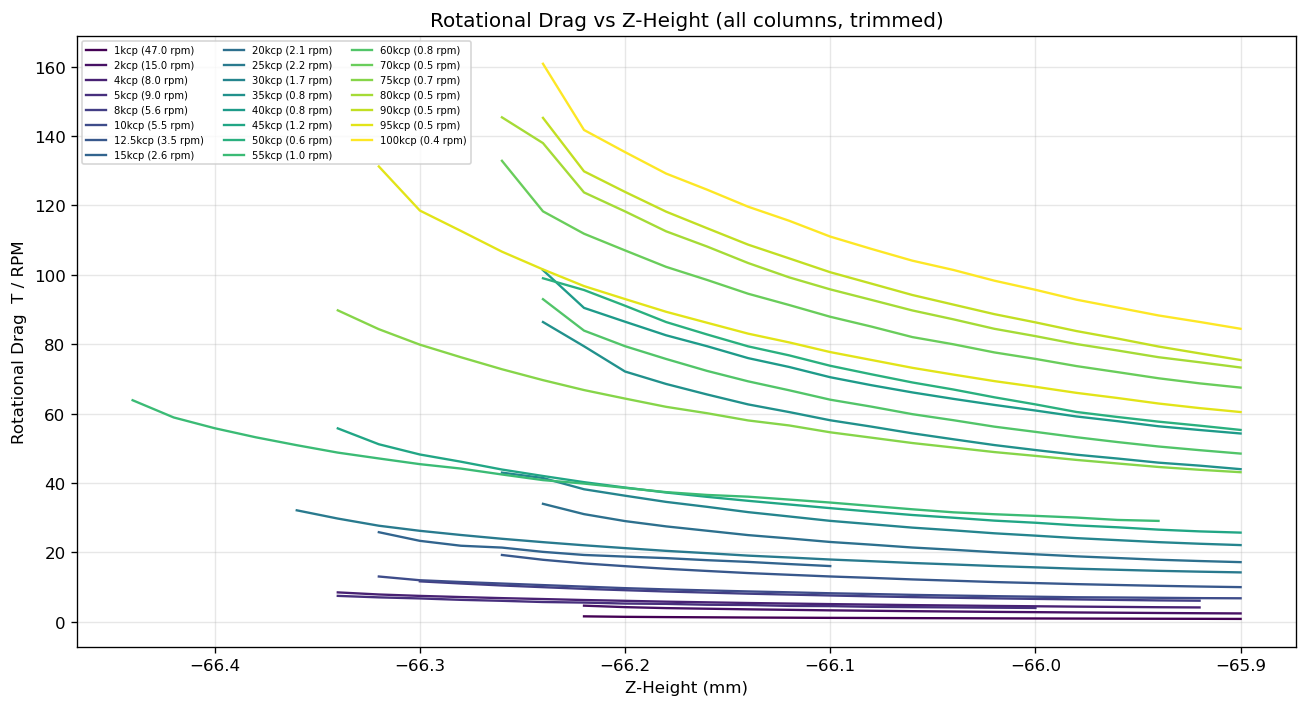

In [10]:
# ── Cell 10: Raw drag vs Z-Height overview plot ───────────────────────────────
colors = cm.viridis(np.linspace(0, 1, len(torque_cols)))

fig, ax = plt.subplots(figsize=(11, 6))
for col, color in zip(torque_cols, colors):
    visc, rpm = col_meta[col]
    h    = drag_df['Height']
    drag = drag_df[col]
    mask = drag.notna()
    ax.plot(h[mask], drag[mask], lw=1.4, color=color, label=f'{visc} ({rpm} rpm)')

ax.set_xlabel('Z-Height (mm)')
ax.set_ylabel('Rotational Drag  T / RPM')
ax.set_title('Rotational Drag vs Z-Height (all columns, trimmed)')
ax.legend(fontsize=6, ncol=3, loc='upper left')
plt.tight_layout()
plt.show()

In [26]:
# ── Cell 11: Method 1 — Direct Space  y = A/(x + B)  (Huber robust fit) ────────
from scipy.optimize import least_squares

def model_direct(x, A, B):
    return A / (x + B)

def huber_residuals(params, x, y, delta=1.0):
    r = y - model_direct(x, *params)
    return np.where(np.abs(r) <= delta,
                    r,
                    delta * np.sign(r) * np.sqrt(2 * np.abs(r) / delta - 1))

fit1 = {}   # col → dict(A, B, y_fit, h_fit)

for col in torque_cols:
    valid = drag_df[col].notna()
    h_raw  = height_norm[col][valid].values
    y_raw  = drag_df[col][valid].values
    # exclude the exact zero (singularity)
    pos    = h_raw > 0
    h, y   = h_raw[pos], y_raw[pos]
    if len(h) < 3:
        fit1[col] = None
        continue
    try:
        p0  = [y.max() * h.min(), y.min()]
        res = least_squares(huber_residuals, p0, args=(h, y), method='trf',
                            loss='huber', f_scale=0.1)
        A, B = res.x
        h_plot  = np.linspace(h.min(), h.max(), 300)
        fit1[col] = dict(A=A, B=B, h_fit=h_plot, y_fit=model_direct(h_plot, A, B),
                         h=h, y=y)
    except Exception as e:
        fit1[col] = None

print('Method 1 fits complete.')

Method 1 fits complete.


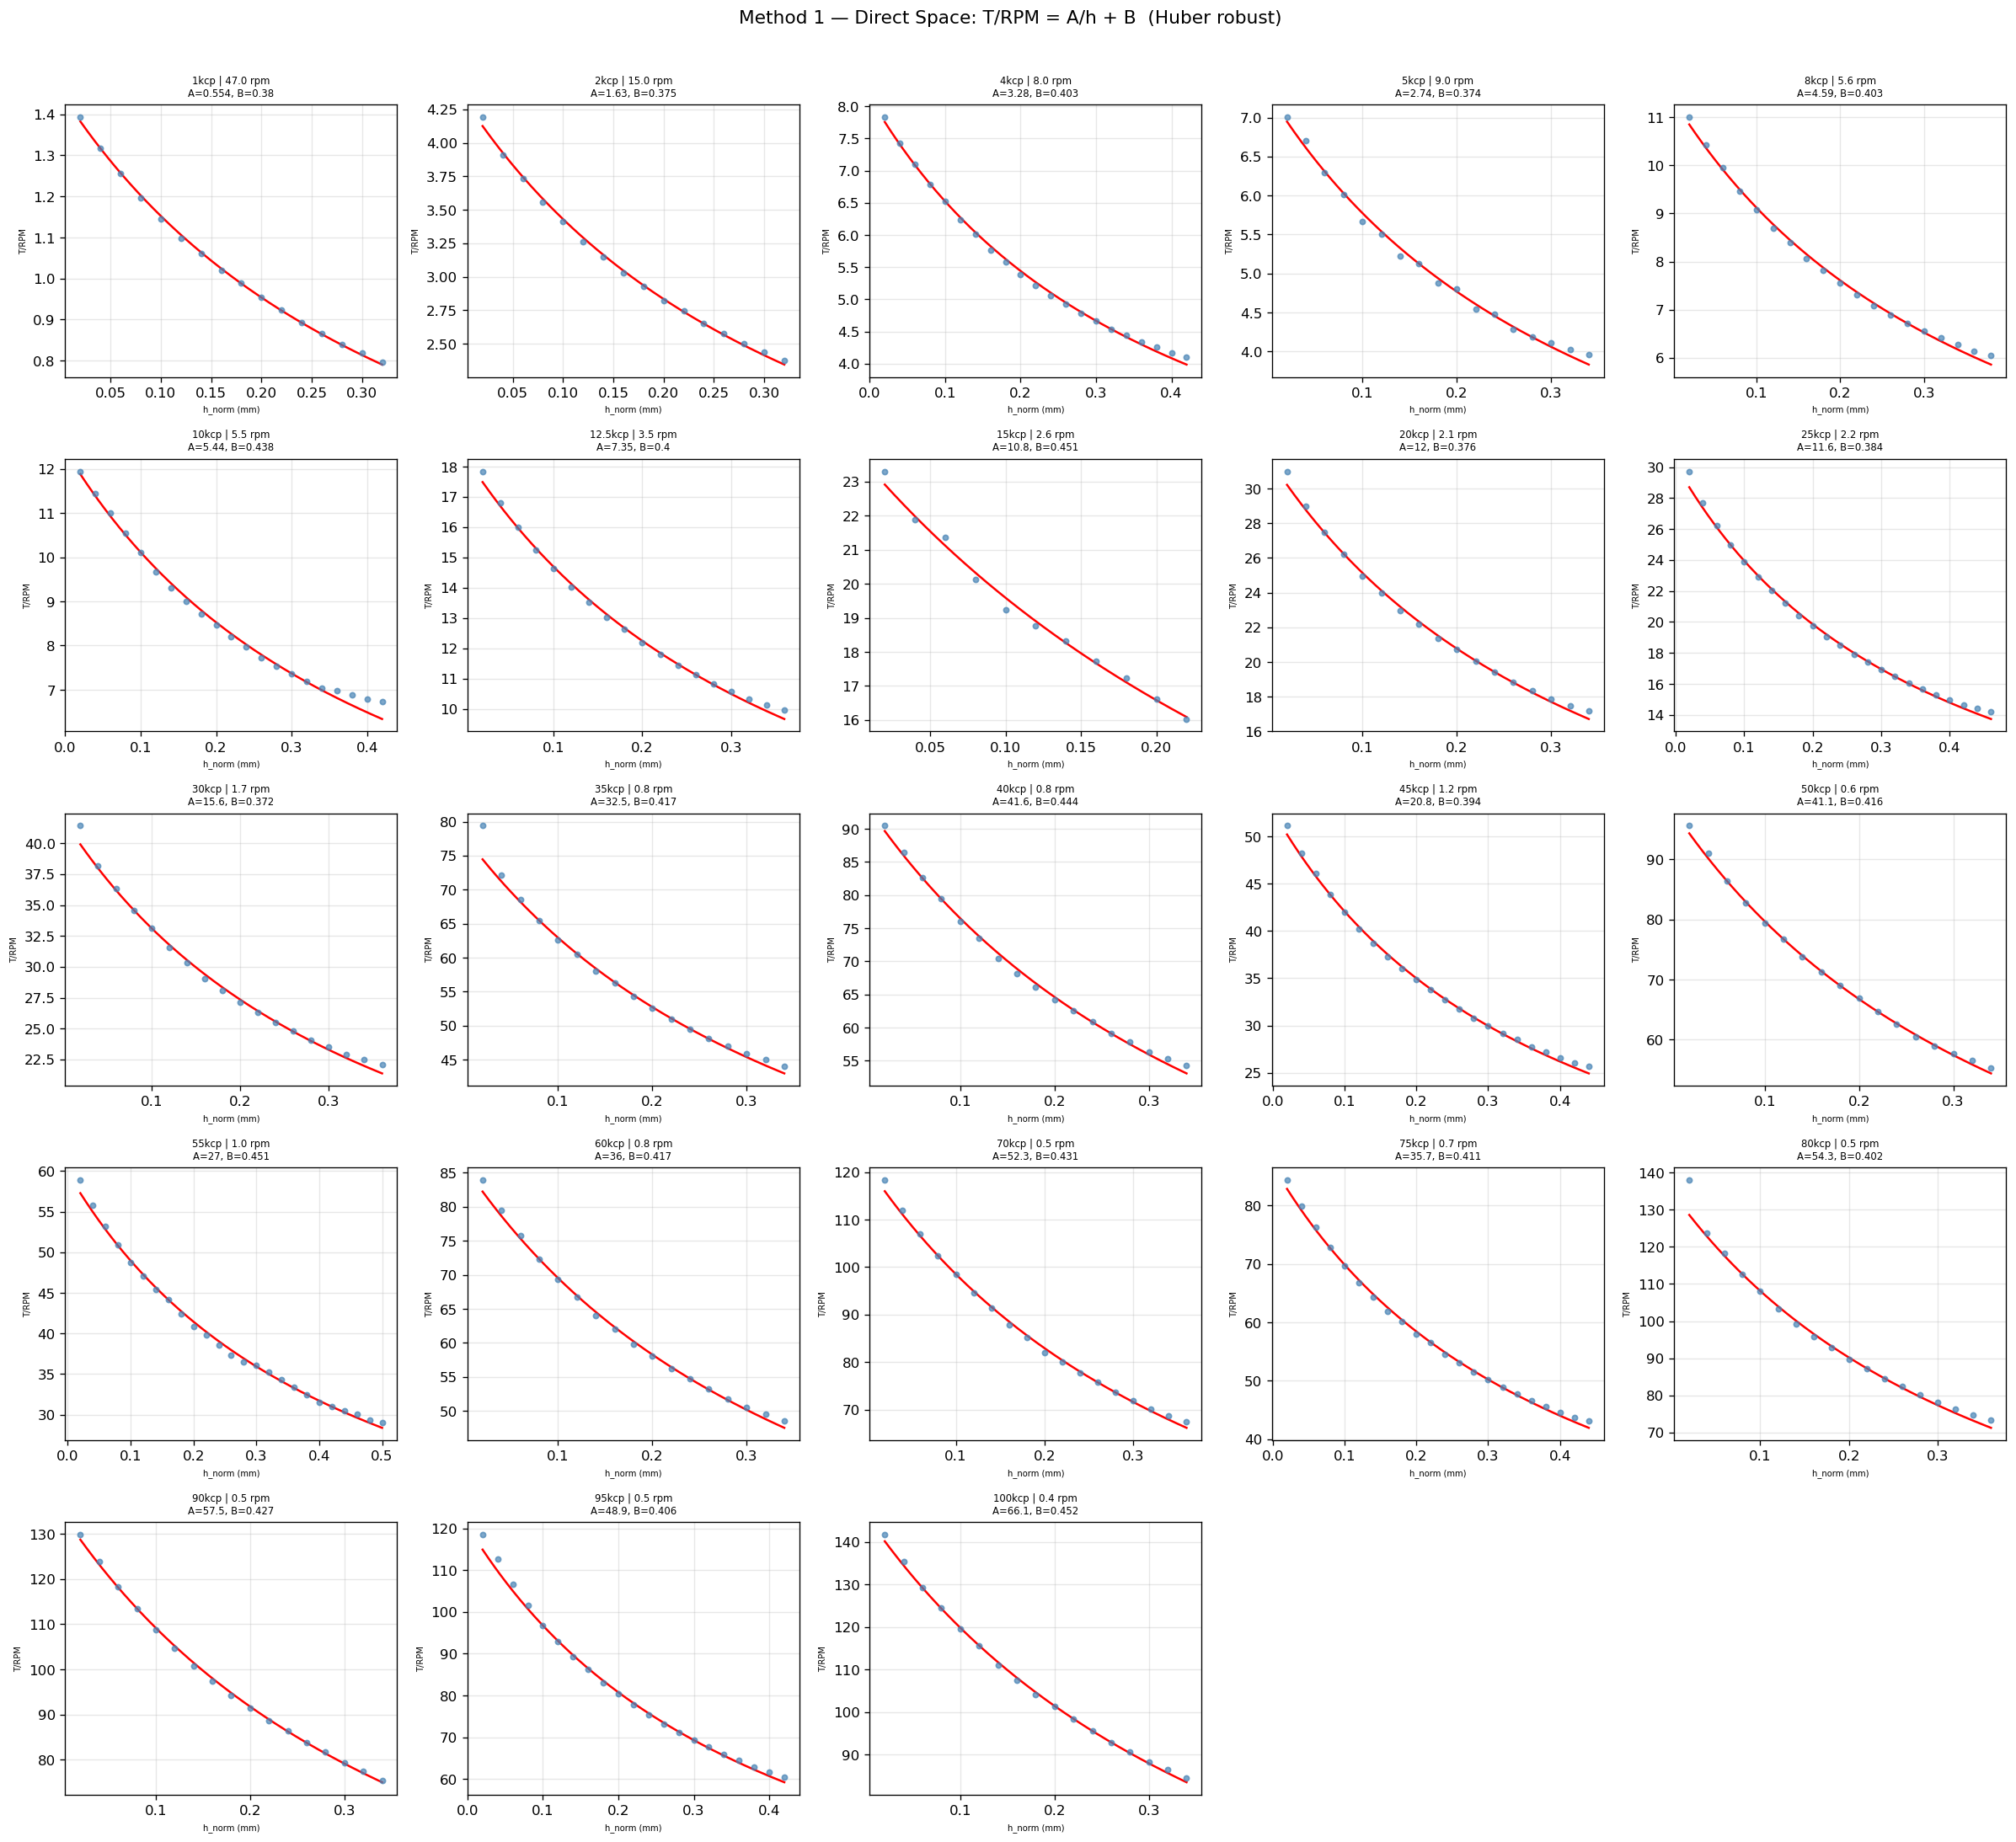

In [27]:
# ── Cell 12: Plot — Method 1 ──────────────────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(20, 18), sharey=False)
axes = axes.flatten()

for ax, col in zip(axes, torque_cols):
    visc, rpm = col_meta[col]
    f = fit1.get(col)
    if f is None:
        ax.set_title(f'{visc}\n(no fit)')
        continue
    ax.scatter(f['h'], f['y'], s=14, color='steelblue', alpha=0.7, zorder=3)
    ax.plot(f['h_fit'], f['y_fit'], 'r-', lw=1.5)
    ax.set_title(f"{visc} | {rpm} rpm\nA={f['A']:.3g}, B={f['B']:.3g}", fontsize=7)
    ax.set_xlabel('h_norm (mm)', fontsize=6)
    ax.set_ylabel('T/RPM', fontsize=6)

for ax in axes[len(torque_cols):]:
    ax.set_visible(False)

fig.suptitle('Method 1 — Direct Space: T/RPM = A/h + B  (Huber robust)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
# ── Cell 13: Method 2 — Reciprocal Space  y = A·(1/h) + B  (WLS) ─────────────
fit2 = {}

for col in torque_cols:
    valid = drag_df[col].notna()
    h_raw = height_norm[col][valid].values
    y_raw = drag_df[col][valid].values
    pos   = h_raw > 0
    h, y  = h_raw[pos], y_raw[pos]
    if len(h) < 3:
        fit2[col] = None
        continue
    X = 1.0 / h          # linearised predictor
    w = h ** 2           # WLS weights  w_i = h_i^2
    # Weighted least squares via numpy
    W   = np.diag(w)
    Xm  = np.column_stack([X, np.ones_like(X)])
    try:
        coeffs = np.linalg.lstsq(Xm.T @ W @ Xm, Xm.T @ W @ y, rcond=None)[0]
        A, B   = coeffs
        X_plot = np.linspace(X.min(), X.max(), 300)
        fit2[col] = dict(A=A, B=B, X=X, y=y, h=h,
                         X_fit=X_plot, y_fit=A * X_plot + B,
                         h_fit=1.0 / X_plot)
    except Exception:
        fit2[col] = None

print('Method 2 fits complete.')


Method 2 fits complete.


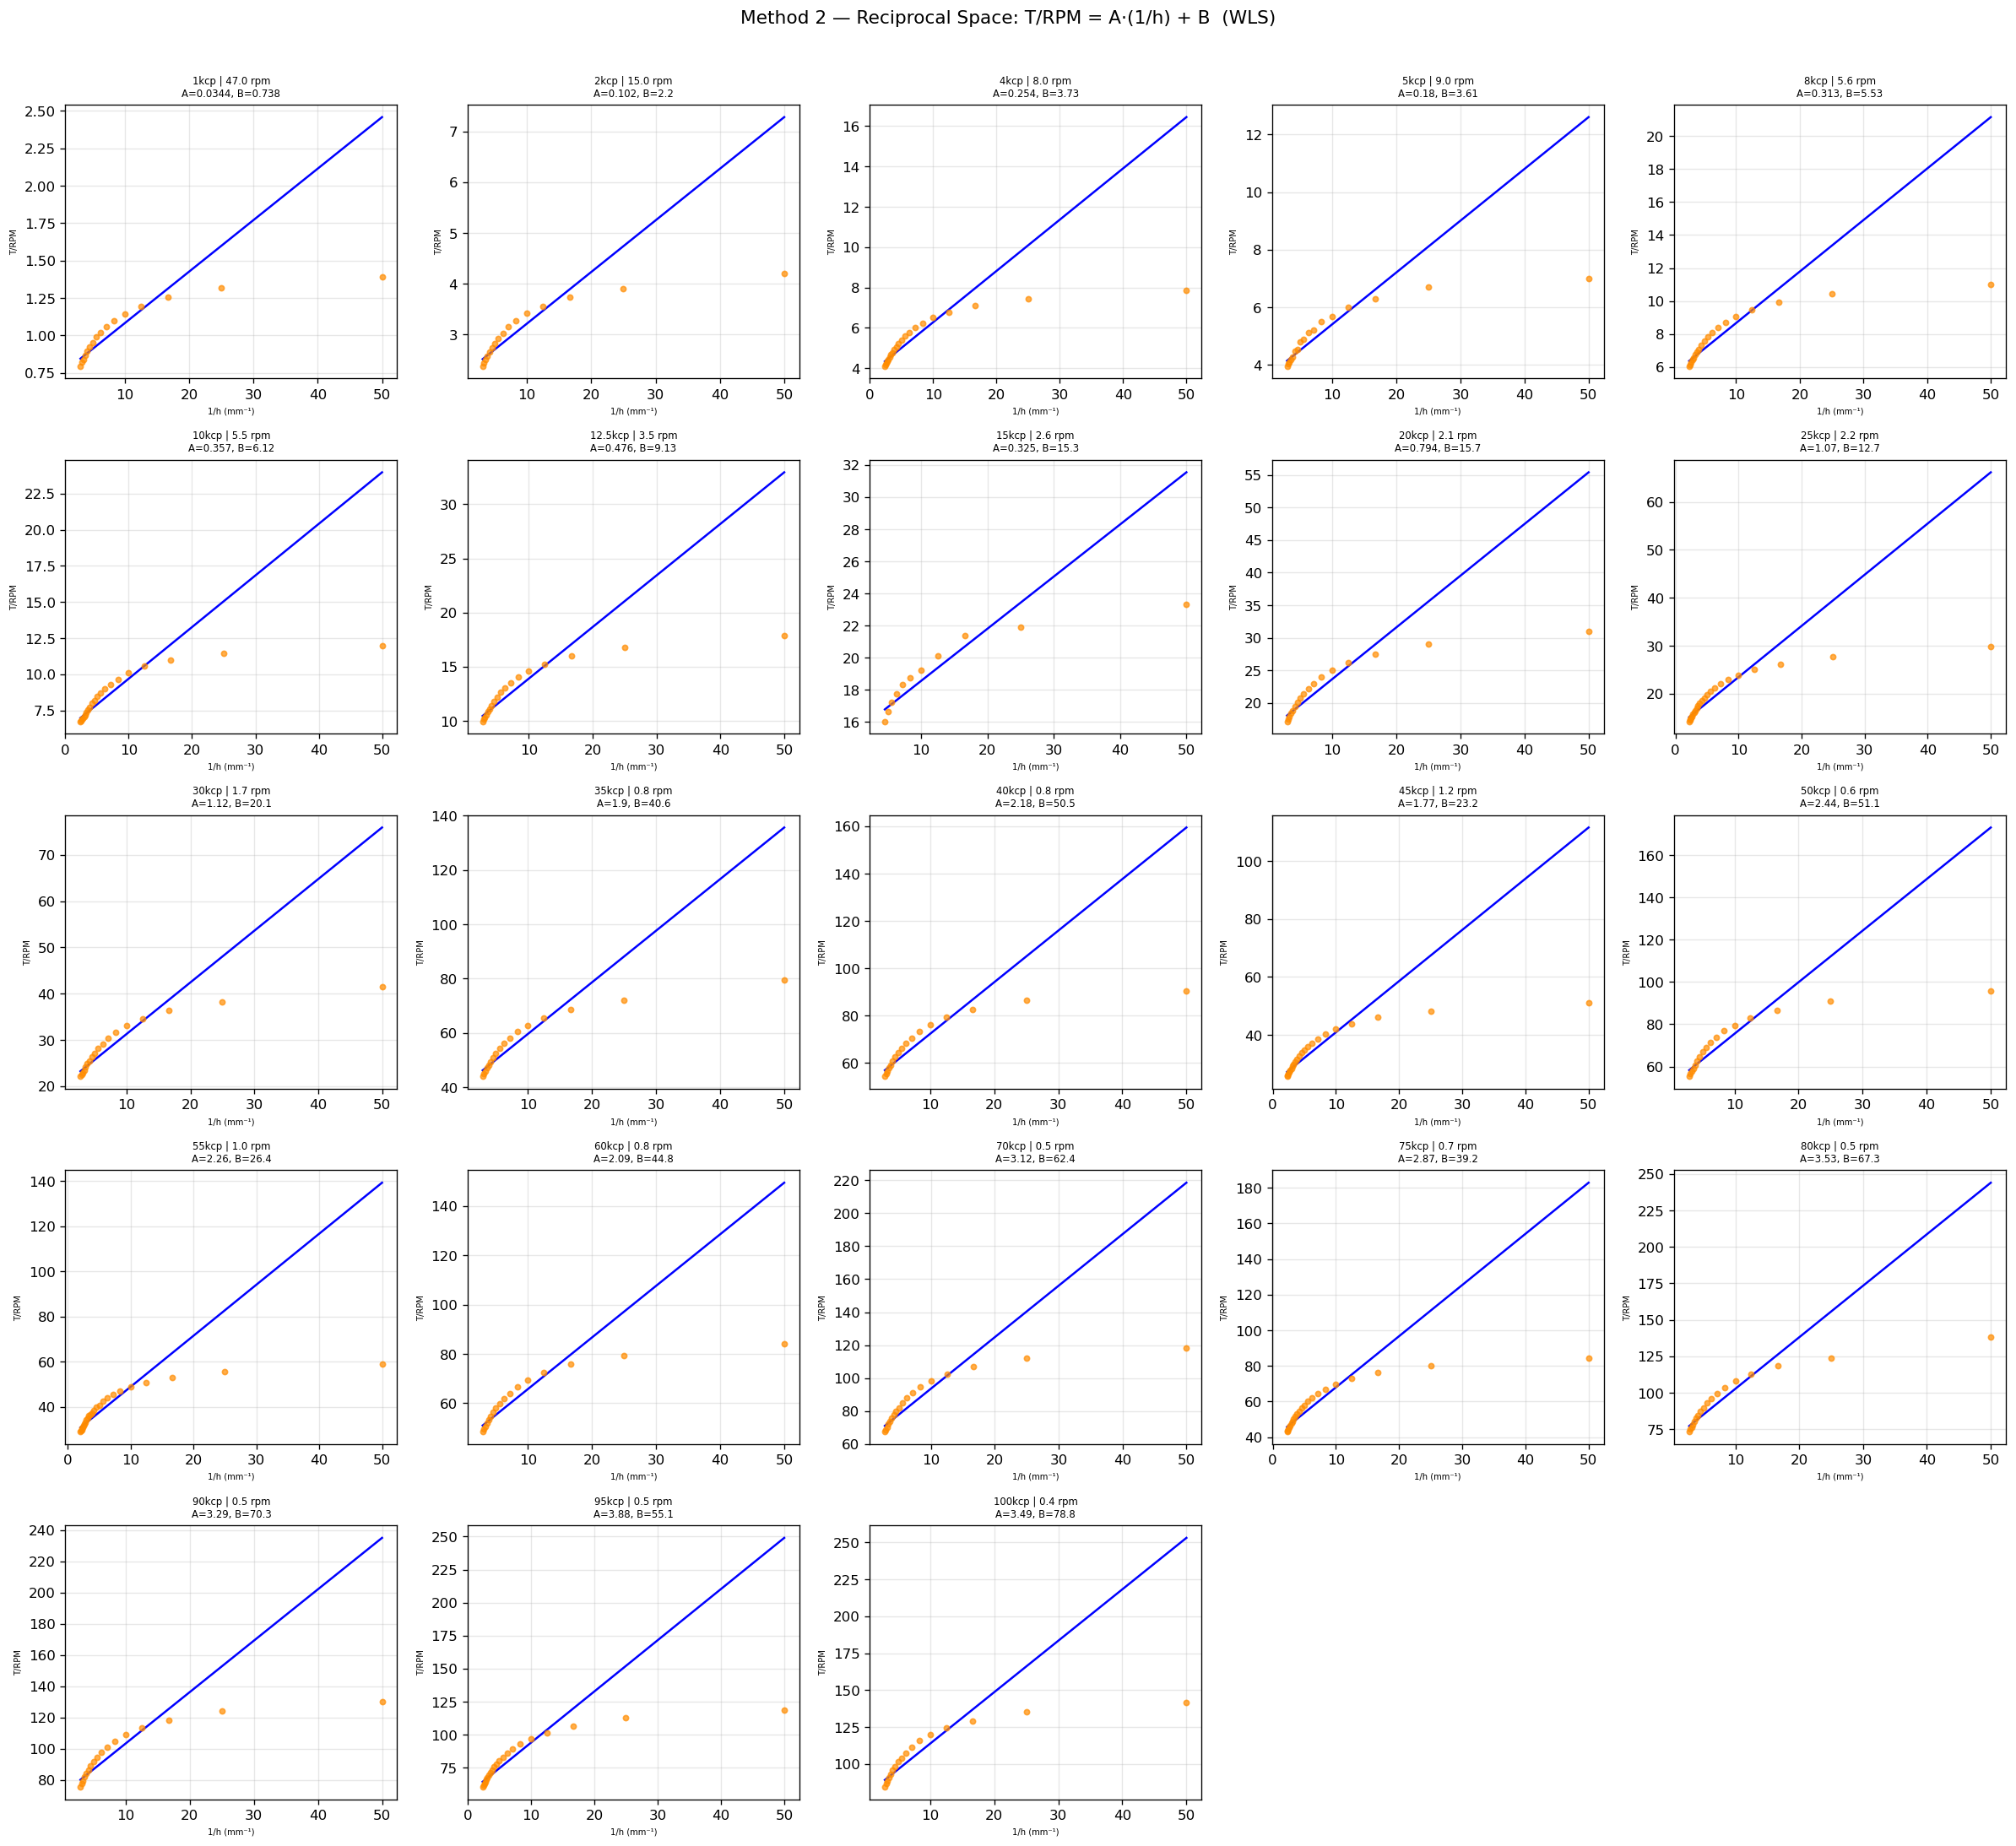

In [29]:
# ── Cell 14: Plot — Method 2 ──────────────────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for ax, col in zip(axes, torque_cols):
    visc, rpm = col_meta[col]
    f = fit2.get(col)
    if f is None:
        ax.set_title(f'{visc}\n(no fit)')
        continue
    ax.scatter(f['X'], f['y'], s=14, color='darkorange', alpha=0.7, zorder=3)
    ax.plot(f['X_fit'], f['y_fit'], 'b-', lw=1.5)
    ax.set_title(f"{visc} | {rpm} rpm\nA={f['A']:.3g}, B={f['B']:.3g}", fontsize=7)
    ax.set_xlabel('1/h (mm⁻¹)', fontsize=6)
    ax.set_ylabel('T/RPM', fontsize=6)

for ax in axes[len(torque_cols):]:
    ax.set_visible(False)

fig.suptitle('Method 2 — Reciprocal Space: T/RPM = A·(1/h) + B  (WLS)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [30]:
# ── Cell 15: Method 3 — Log-Log Space  log(y) = log(A) - m·log(h)  (OLS) ─────
fit3 = {}

for col in torque_cols:
    valid = drag_df[col].notna()
    h_raw = height_norm[col][valid].values
    y_raw = drag_df[col][valid].values
    pos   = (h_raw > 0) & (y_raw > 0)    # log requires strictly positive
    h, y  = h_raw[pos], y_raw[pos]
    if len(h) < 3:
        fit3[col] = None
        continue
    lh, ly = np.log(h), np.log(y)
    slope, intercept, r, p, se = linregress(lh, ly)
    # back-transform: y = exp(intercept) * h^slope
    A = np.exp(intercept)     # viscosity factor
    m = -slope                # should be ≈ +1 for Newtonian
    h_plot  = np.linspace(h.min(), h.max(), 300)
    fit3[col] = dict(A=A, m=m, r2=r**2,
                     lh=lh, ly=ly, h=h, y=y,
                     h_fit=h_plot, y_fit=A * h_plot**(-m))

print('Method 3 fits complete.')
print('Slope m (expect ≈ 1 for Newtonian):')
for col in torque_cols:
    f = fit3.get(col)
    if f:
        visc, _ = col_meta[col]
        print(f'  {visc:20s}  m={f["m"]:.3f}  R²={f["r2"]:.4f}')

Method 3 fits complete.
Slope m (expect ≈ 1 for Newtonian):
  1kcp                  m=0.214  R²=0.9326
  2kcp                  m=0.216  R²=0.9406
  4kcp                  m=0.237  R²=0.9340
  5kcp                  m=0.223  R²=0.9427
  8kcp                  m=0.225  R²=0.9410
  10kcp                 m=0.218  R²=0.9392
  12.5kcp               m=0.220  R²=0.9429
  15kcp                 m=0.155  R²=0.9456
  20kcp                 m=0.225  R²=0.9469
  25kcp                 m=0.261  R²=0.9415
  30kcp                 m=0.235  R²=0.9517
  35kcp                 m=0.218  R²=0.9601
  40kcp                 m=0.197  R²=0.9372
  45kcp                 m=0.248  R²=0.9352
  50kcp                 m=0.209  R²=0.9320
  55kcp                 m=0.247  R²=0.9329
  60kcp                 m=0.210  R²=0.9406
  70kcp                 m=0.211  R²=0.9376
  75kcp                 m=0.242  R²=0.9348
  80kcp                 m=0.229  R²=0.9613
  90kcp                 m=0.205  R²=0.9299
  95kcp                 m=0.245  R²=0

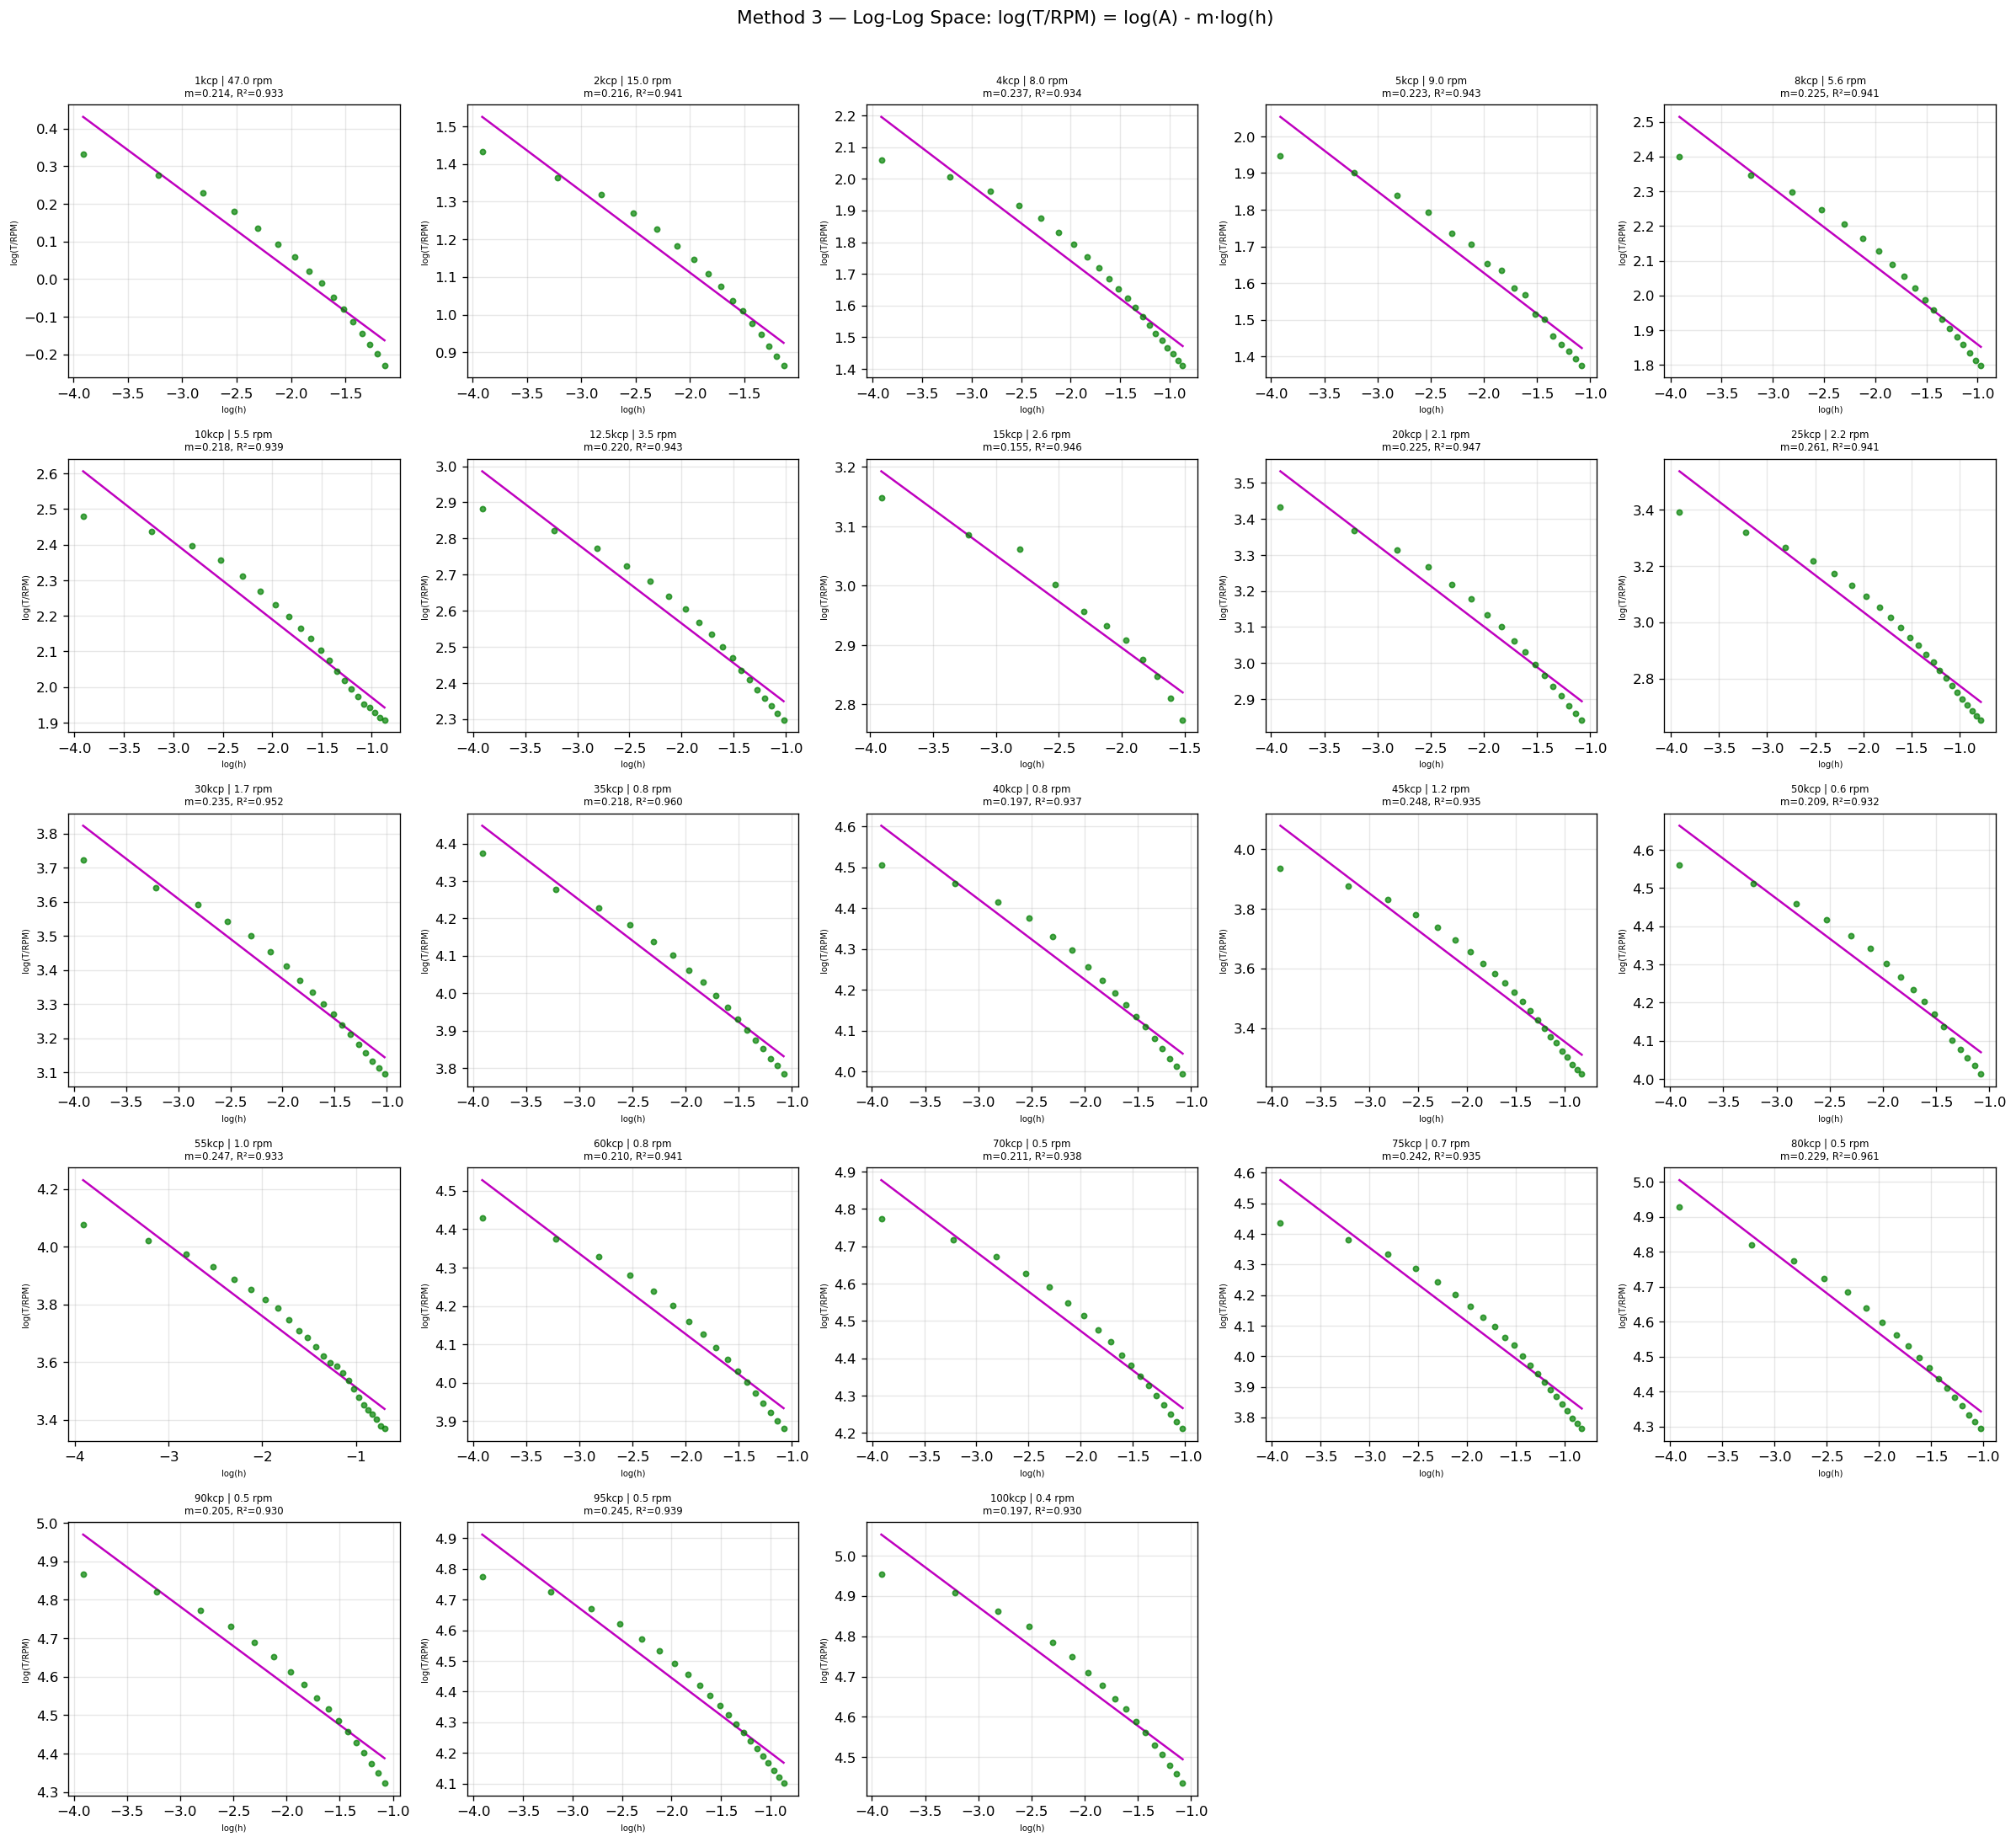

In [31]:
# ── Cell 16: Plot — Method 3 (log-log) ───────────────────────────────────────
fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for ax, col in zip(axes, torque_cols):
    visc, rpm = col_meta[col]
    f = fit3.get(col)
    if f is None:
        ax.set_title(f'{visc}\n(no fit)')
        continue
    ax.scatter(np.log(f['h']), f['ly'], s=14, color='green', alpha=0.7, zorder=3)
    ax.plot(np.log(f['h_fit']), np.log(f['y_fit']), 'm-', lw=1.5)
    ax.set_title(f"{visc} | {rpm} rpm\nm={f['m']:.3f}, R²={f['r2']:.3f}", fontsize=7)
    ax.set_xlabel('log(h)', fontsize=6)
    ax.set_ylabel('log(T/RPM)', fontsize=6)

for ax in axes[len(torque_cols):]:
    ax.set_visible(False)

fig.suptitle('Method 3 — Log-Log Space: log(T/RPM) = log(A) - m·log(h)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [32]:
# ── Cell 17: Method 4 — Dual-Parameter Linearisation  (T/RPM)·h = A + B·h ───
fit4 = {}

for col in torque_cols:
    valid = drag_df[col].notna()
    h_raw = height_norm[col][valid].values
    y_raw = drag_df[col][valid].values
    pos   = h_raw > 0
    h, y  = h_raw[pos], y_raw[pos]
    if len(h) < 3:
        fit4[col] = None
        continue
    # Transform: z = (T/RPM) * h   →   z = A + B*h
    z  = y * h
    Xm = np.column_stack([np.ones_like(h), h])
    coeffs, *_ = np.linalg.lstsq(Xm, z, rcond=None)
    A, B = coeffs          # A = viscosity factor (y-intercept), B = machine drag (slope)
    h_plot = np.linspace(h.min(), h.max(), 300)
    fit4[col] = dict(A=A, B=B, h=h, y=y, z=z,
                     h_fit=h_plot, z_fit=A + B * h_plot,
                     # recover drag in original space
                     y_fit=(A + B * h_plot) / h_plot)

print('Method 4 fits complete.')


Method 4 fits complete.


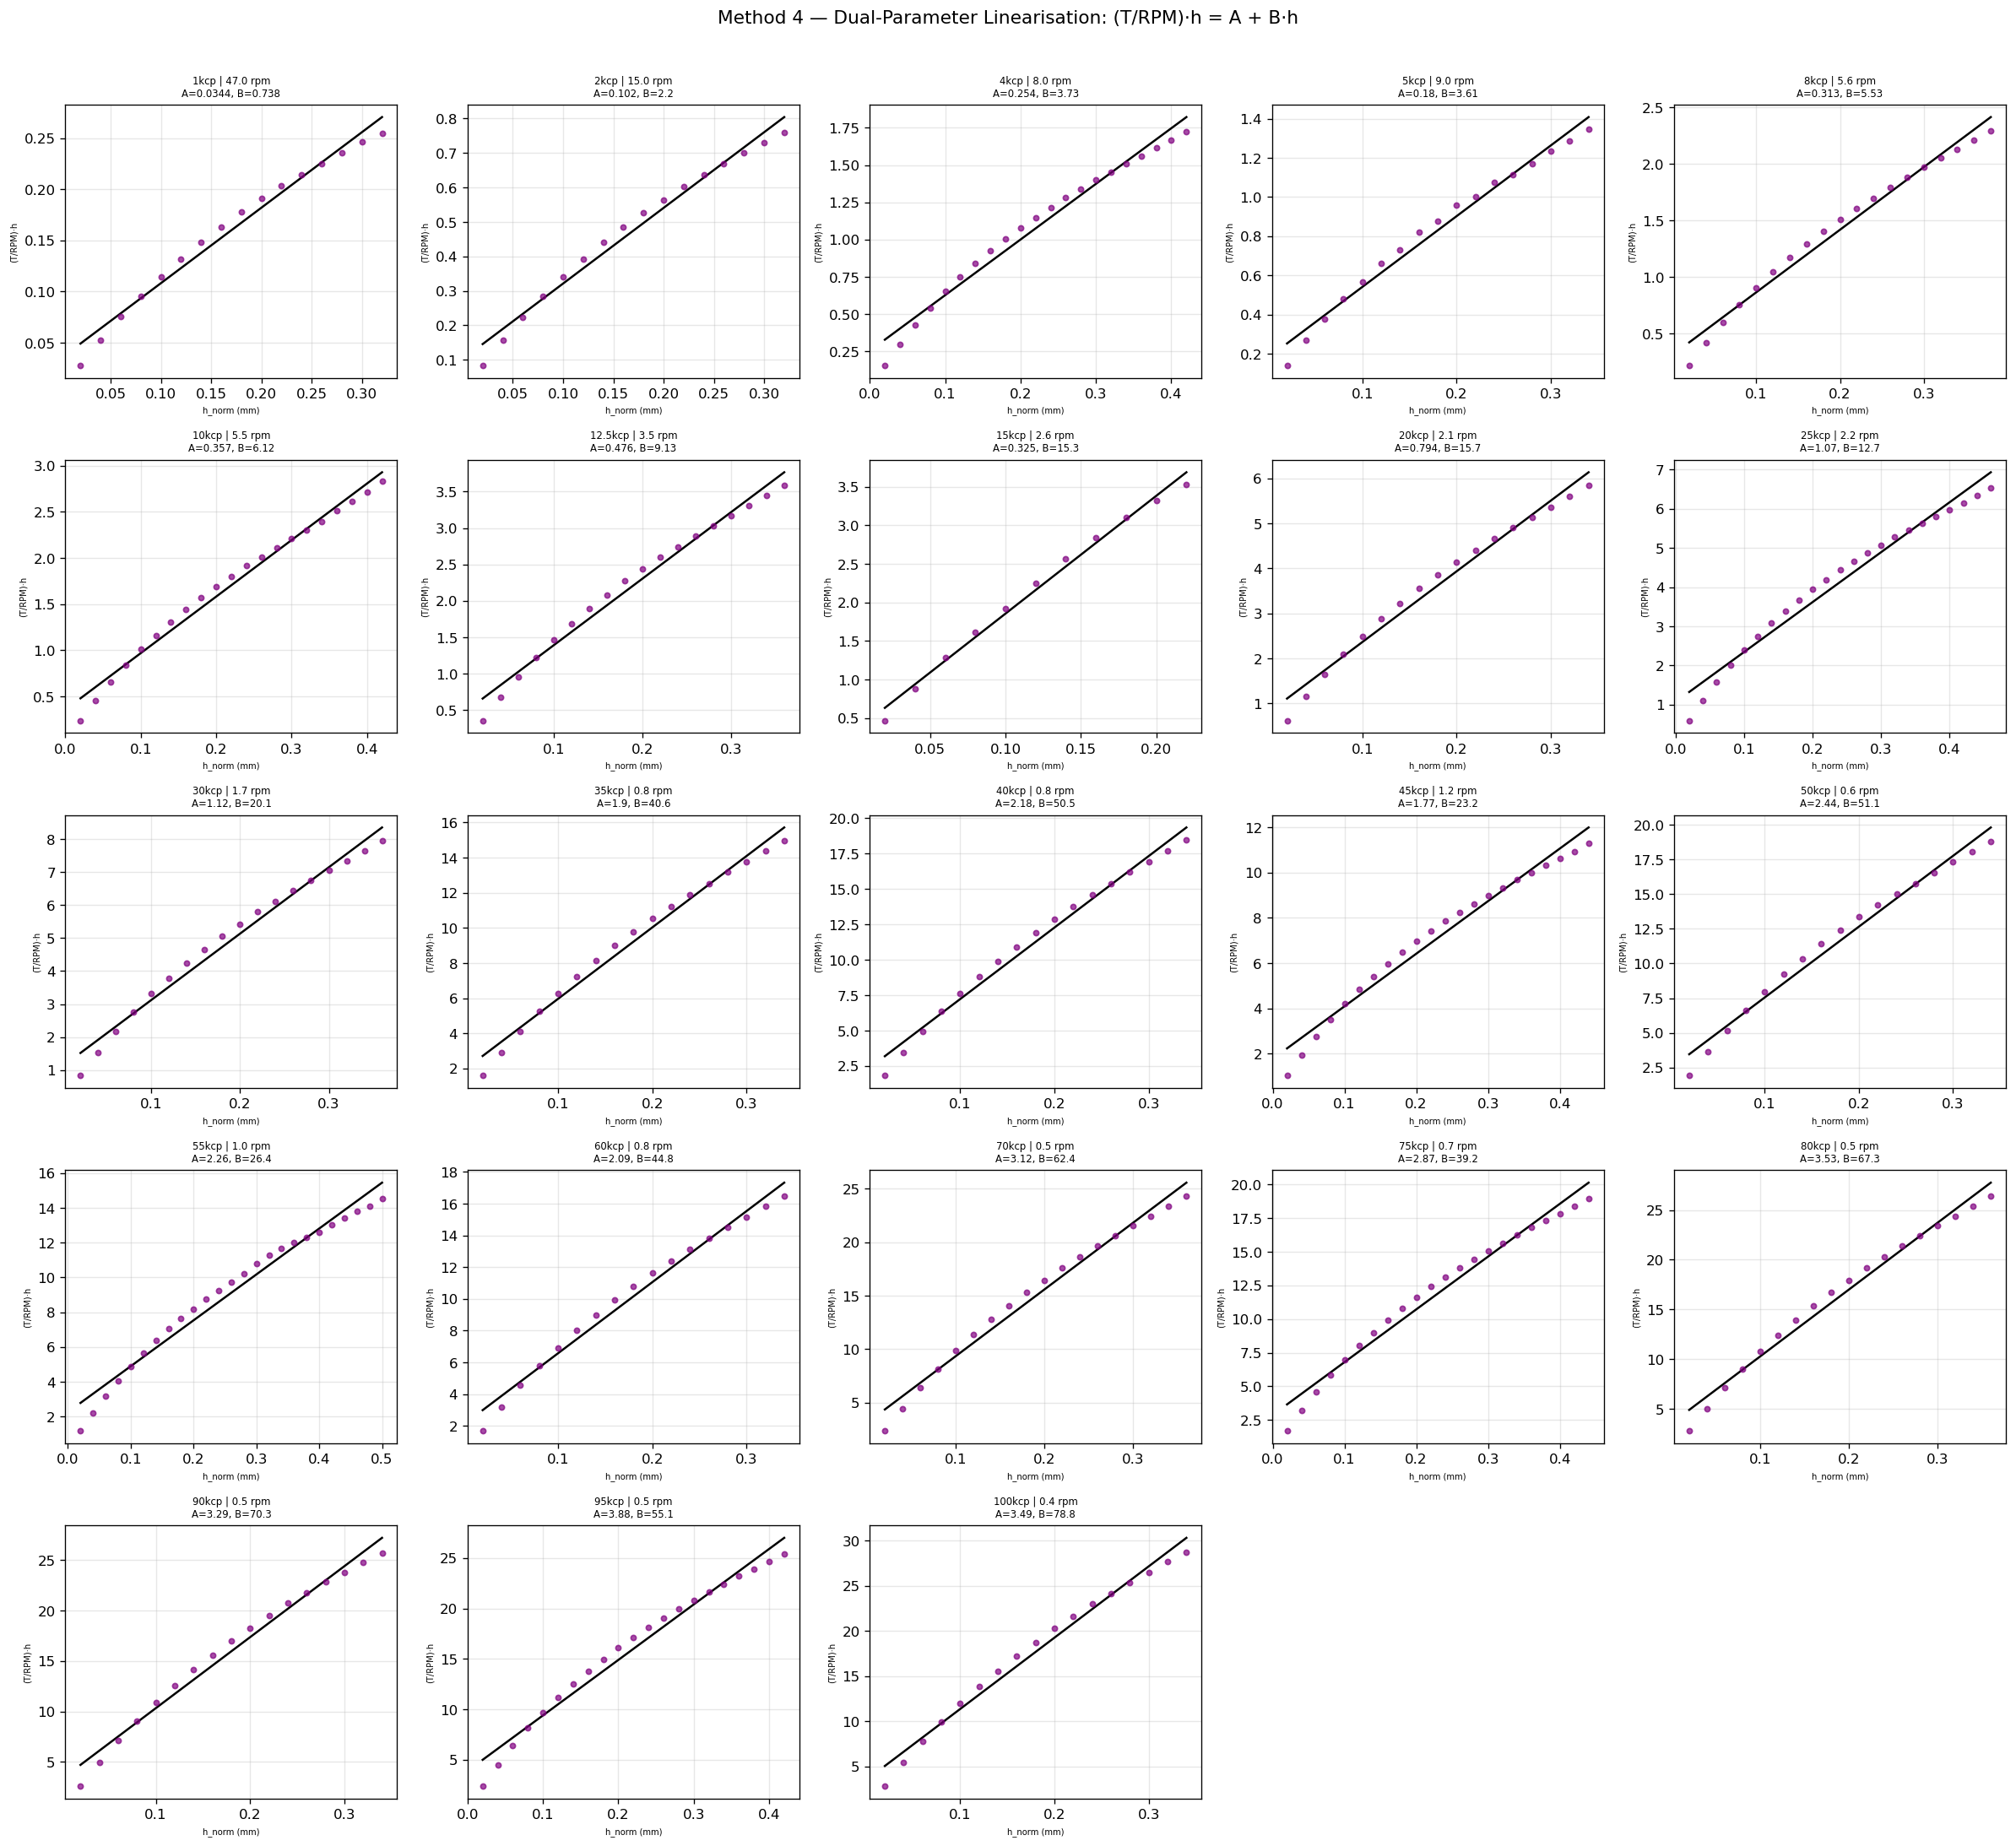

In [33]:
# ── Cell 18: Plot — Method 4 (linearised product space) ──────────────────────
fig, axes = plt.subplots(5, 5, figsize=(20, 18))
axes = axes.flatten()

for ax, col in zip(axes, torque_cols):
    visc, rpm = col_meta[col]
    f = fit4.get(col)
    if f is None:
        ax.set_title(f'{visc}\n(no fit)')
        continue
    ax.scatter(f['h'], f['z'], s=14, color='purple', alpha=0.7, zorder=3)
    ax.plot(f['h_fit'], f['z_fit'], 'k-', lw=1.5)
    ax.set_title(f"{visc} | {rpm} rpm\nA={f['A']:.3g}, B={f['B']:.3g}", fontsize=7)
    ax.set_xlabel('h_norm (mm)', fontsize=6)
    ax.set_ylabel('(T/RPM)·h', fontsize=6)

for ax in axes[len(torque_cols):]:
    ax.set_visible(False)

fig.suptitle('Method 4 — Dual-Parameter Linearisation: (T/RPM)·h = A + B·h', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [34]:
# ── Cell 19: Summary table — extracted A (viscosity factor) from all 4 methods
summary_rows = []
for col in torque_cols:
    visc, rpm = col_meta[col]
    row = dict(Column=col, Viscosity_Label=visc, RPM=rpm)
    for tag, store in [('M1_A', fit1), ('M2_A', fit2), ('M3_A', fit3), ('M4_A', fit4)]:
        f = store.get(col)
        row[tag] = f['A'] if f else np.nan
    # Method 3 also extracts slope m
    f3 = fit3.get(col)
    row['M3_slope_m'] = f3['m'] if f3 else np.nan
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
pd.set_option('display.float_format', '{:.4g}'.format)
print('Extracted viscosity factor A and machine-drag B:')
summary_df[['Viscosity_Label','RPM','M1_A','M2_A','M3_A','M4_A','M3_slope_m']]

Extracted viscosity factor A and machine-drag B:


,Viscosity_Label,RPM,M1_A,M2_A,M3_A,M4_A,M3_slope_m
0,1kcp,47,0.5538,0.03441,0.6659,0.03441,0.2142
1,2kcp,15,1.628,0.1017,1.971,0.1017,0.2164
2,4kcp,8,3.282,0.2542,3.547,0.2542,0.2375
3,5kcp,9,2.737,0.1798,3.263,0.1798,0.2226
4,8kcp,5.6,4.588,0.3126,5.126,0.3126,0.2249
5,10kcp,5.5,5.436,0.3572,5.775,0.3572,0.218
6,12.5kcp,3.5,7.349,0.4762,8.37,0.4762,0.2202
7,15kcp,2.6,10.8,0.325,13.26,0.325,0.1554
8,20kcp,2.1,11.96,0.7941,14.17,0.7941,0.2253
9,25kcp,2.2,11.59,1.069,12.35,1.069,0.2615


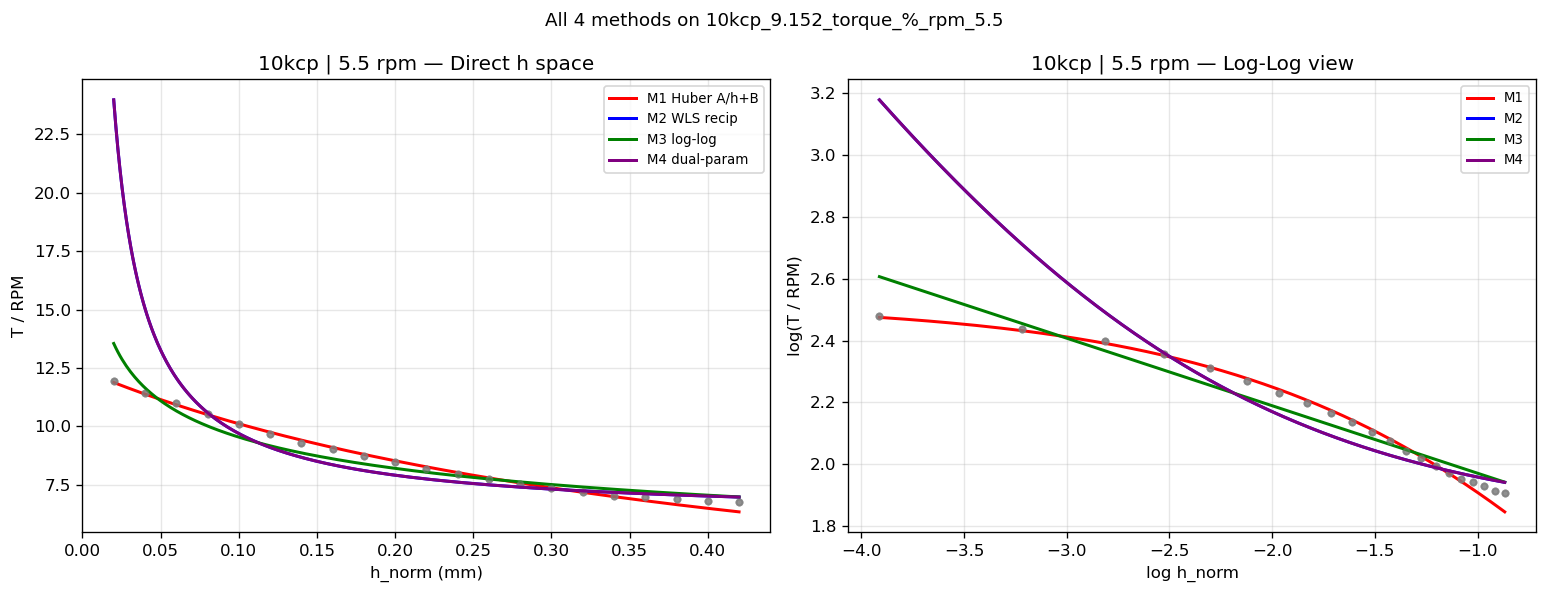

In [35]:
# ── Cell 20: Overlay — all 4 methods on one example column ───────────────────
# Change this to any column you want to inspect
EXAMPLE_COL = '10kcp_9.152_torque_%_rpm_5.5'

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

visc, rpm = col_meta[EXAMPLE_COL]
title_base = f'{visc} | {rpm} rpm'

# Left: direct h space
ax = axes[0]
ax.set_title(f'{title_base} — Direct h space')
ax.set_xlabel('h_norm (mm)')
ax.set_ylabel('T / RPM')

for tag, store, color, label in [
    ('M1', fit1, 'red',    'M1 Huber A/h+B'),
    ('M2', fit2, 'blue',   'M2 WLS recip'),
    ('M3', fit3, 'green',  'M3 log-log'),
    ('M4', fit4, 'purple', 'M4 dual-param'),
]:
    f = store.get(EXAMPLE_COL)
    if f is None:
        continue
    ax.scatter(f['h'], f['y'], s=14, color='grey', alpha=0.4, zorder=2)
    ax.plot(f['h_fit'], f['y_fit'], color=color, lw=1.8, label=label)

ax.legend(fontsize=8)

# Right: log-log view
ax = axes[1]
ax.set_title(f'{title_base} — Log-Log view')
ax.set_xlabel('log h_norm')
ax.set_ylabel('log(T / RPM)')

for tag, store, color, label in [
    ('M1', fit1, 'red',    'M1'),
    ('M2', fit2, 'blue',   'M2'),
    ('M3', fit3, 'green',  'M3'),
    ('M4', fit4, 'purple', 'M4'),
]:
    f = store.get(EXAMPLE_COL)
    if f is None:
        continue
    ax.scatter(np.log(f['h']), np.log(f['y']), s=14, color='grey', alpha=0.4, zorder=2)
    ax.plot(np.log(f['h_fit']), np.log(f['y_fit']), color=color, lw=1.8, label=label)

ax.legend(fontsize=8)

plt.suptitle(f'All 4 methods on {EXAMPLE_COL}', fontsize=11)
plt.tight_layout()
plt.show()

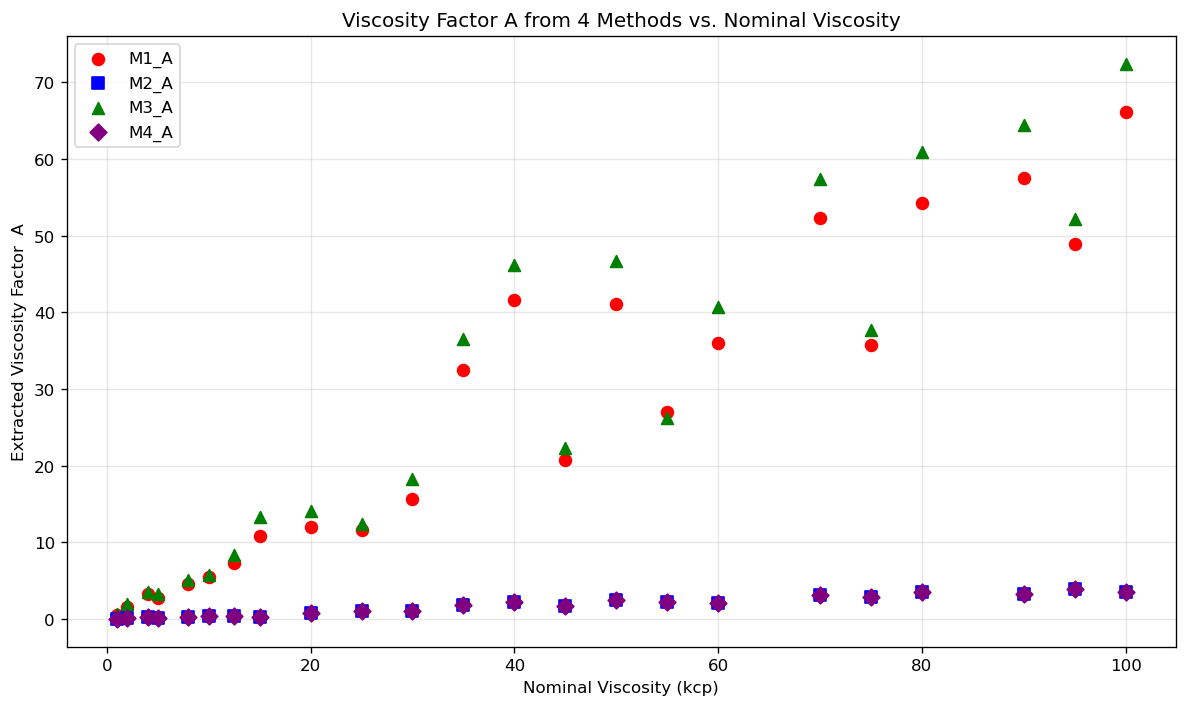

In [36]:
# ── Cell 21: Viscosity factor A vs labelled viscosity (all 4 methods) ────────
# Extract numeric viscosity from label e.g. '12.5kcp' → 12.5
def label_to_kcp(label):
    return float(label.lower().replace('kcp', ''))

summary_df['visc_kcp'] = summary_df['Viscosity_Label'].apply(label_to_kcp)

fig, ax = plt.subplots(figsize=(10, 6))
for tag, color, marker in [
    ('M1_A', 'red',    'o'),
    ('M2_A', 'blue',   's'),
    ('M3_A', 'green',  '^'),
    ('M4_A', 'purple', 'D'),
]:
    ax.scatter(summary_df['visc_kcp'], summary_df[tag],
               color=color, marker=marker, s=50, label=tag, zorder=4)

ax.set_xlabel('Nominal Viscosity (kcp)')
ax.set_ylabel('Extracted Viscosity Factor  A')
ax.set_title('Viscosity Factor A from 4 Methods vs. Nominal Viscosity')
ax.legend()
plt.tight_layout()
plt.show()